# 🏆 IMC Prosperity 4 — Market Analysis Notebook

**Products:** `TOMATOES`, `EMERALDS`  
**Days available:** Day -2, Day -1  

---

### What this notebook covers
1. **Data loading & overview** — shape, types, missing values
2. **Mid-price dynamics** — trends, stationarity, regime changes
3. **Order book analysis** — bid-ask spread, depth, imbalance
4. **Trade flow analysis** — volume, frequency, price impact
5. **Fair value estimation** — VWAP, weighted mid, order book imbalance signal
6. **Market-making metrics** — optimal spread, inventory risk proxies
7. **Cross-product correlation** — EMERALDS vs TOMATOES relationship
8. **Actionable signals summary**

## 0. Imports & Setup

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# ── Plotting style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
})
COLORS = {'ASH_COATED_OSMIUM': "#161917", 'INTARIAN_PEPPER_ROOT': "#c39f2b"}

# ── File paths — adjust if needed ───────────────────────────────────────────
PRICE_FILES = [
    'prices_round_2_day_-1.csv',
    'prices_round_2_day_0.csv',
    'prices_round_2_day_1.csv',
]
TRADE_FILES = [
    'trades_round_2_day_-1.csv',
    'trades_round_2_day_0.csv',
    'trades_round_2_day_1.csv',
]

print('Setup complete ✓')

Setup complete ✓


## 1. Data Loading & Overview

In [5]:
prices = pd.concat(
    [pd.read_csv(f, sep=';') for f in PRICE_FILES],
    ignore_index=True
).sort_values(['day', 'timestamp']).reset_index(drop=True)

trades = pd.concat(
    [pd.read_csv(f, sep=';') for f in TRADE_FILES],
    ignore_index=True
).sort_values('timestamp').reset_index(drop=True)

# Rename 'symbol' → 'product' for consistency
trades = trades.rename(columns={'symbol': 'product'})

PRODUCTS = prices['product'].unique().tolist()
DAYS     = sorted(prices['day'].unique().tolist())

print(f'Prices:  {prices.shape[0]:,} rows × {prices.shape[1]} cols')
print(f'Trades:  {trades.shape[0]:,} rows × {trades.shape[1]} cols')
print(f'Products: {PRODUCTS}')
print(f'Days:     {DAYS}')
print(f'Timestamp range: {prices["timestamp"].min()} → {prices["timestamp"].max()}')

Prices:  60,000 rows × 17 cols
Trades:  2,391 rows × 7 cols
Products: ['INTARIAN_PEPPER_ROOT', 'ASH_COATED_OSMIUM']
Days:     [-1, 0, 1]
Timestamp range: 0 → 999900


In [6]:
# ── Per-product summary statistics ──────────────────────────────────────────
rows = []
for prod in PRODUCTS:
    p = prices[prices['product'] == prod].copy()
    p['spread'] = p['ask_price_1'] - p['bid_price_1']
    t = trades[trades['product'] == prod]
    rows.append({
        'Product': prod,
        'Mid price mean': p['mid_price'].mean(),
        'Mid price std':  p['mid_price'].std(),
        'Spread mean':    p['spread'].mean(),
        'Spread std':     p['spread'].std(),
        'Trade count':    len(t),
        'Avg trade qty':  t['quantity'].mean(),
        'Total volume':   t['quantity'].sum(),
    })

summary = pd.DataFrame(rows).set_index('Product')
print(summary.round(3).to_string())

                      Mid price mean  Mid price std  Spread mean  Spread std  Trade count  Avg trade qty  Total volume
Product                                                                                                               
INTARIAN_PEPPER_ROOT       12480.333        996.637       14.122       2.788          996          5.053          5033
ASH_COATED_OSMIUM           9983.211        420.021       16.234       2.520         1395          5.109          7127


In [7]:
# ── Missing / NaN audit (3rd level order book) ──────────────────────────────
for col in ['bid_price_1', 'bid_volume_1', 'ask_price_1', 'ask_volume_1']:
    pct = prices[col].isna().mean() * 100
    print(f'{col:20s}  {pct:5.1f}% missing')

bid_price_1             3.9% missing
bid_volume_1            3.9% missing
ask_price_1             3.9% missing
ask_volume_1            3.9% missing


## 2. Mid-Price Dynamics

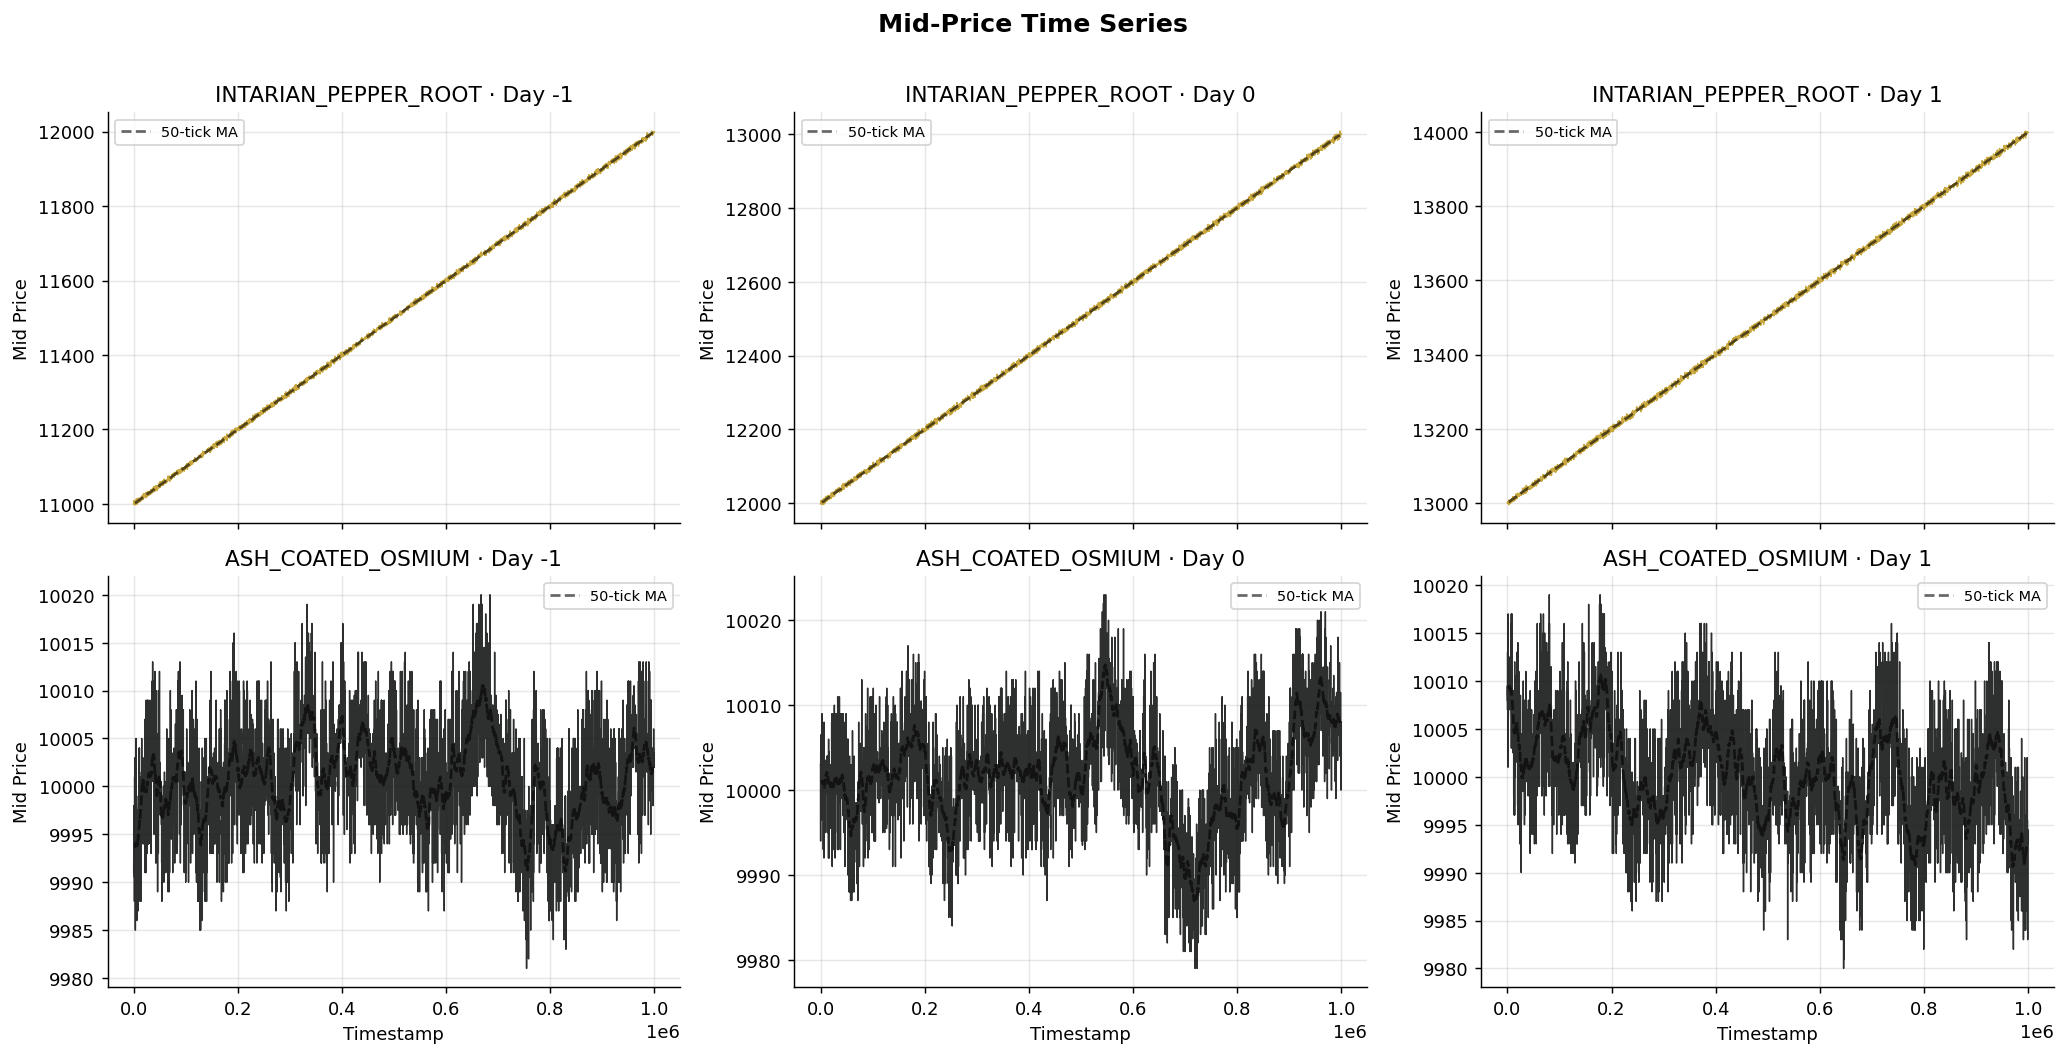

In [9]:
fig, axes = plt.subplots(len(PRODUCTS), len(DAYS), figsize=(16, 4*len(PRODUCTS)), sharex='col')
if len(PRODUCTS) == 1:
    axes = axes[np.newaxis, :]

for row_i, prod in enumerate(PRODUCTS):
    for col_i, day in enumerate(DAYS):
        ax = axes[row_i, col_i]
        
        sub = prices[
            (prices['product'] == prod) &
            (prices['day'] == day) &
            (prices['mid_price'] != 0)   # remove zero values
        ].copy()

        ax.plot(sub['timestamp'], sub['mid_price'],
                color=COLORS.get(prod, 'steelblue'), linewidth=0.8, alpha=0.9)

        # Rolling mean (50-tick window)
        roll = sub['mid_price'].rolling(50, center=True).mean()
        ax.plot(sub['timestamp'], roll,
                color='black', linewidth=1.5,
                linestyle='--', alpha=0.6, label='50-tick MA')

        ax.set_title(f'{prod} · Day {day}')
        ax.set_ylabel('Mid Price')
        if row_i == len(PRODUCTS)-1:
            ax.set_xlabel('Timestamp')
        ax.legend(fontsize=8)

plt.suptitle('Mid-Price Time Series', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

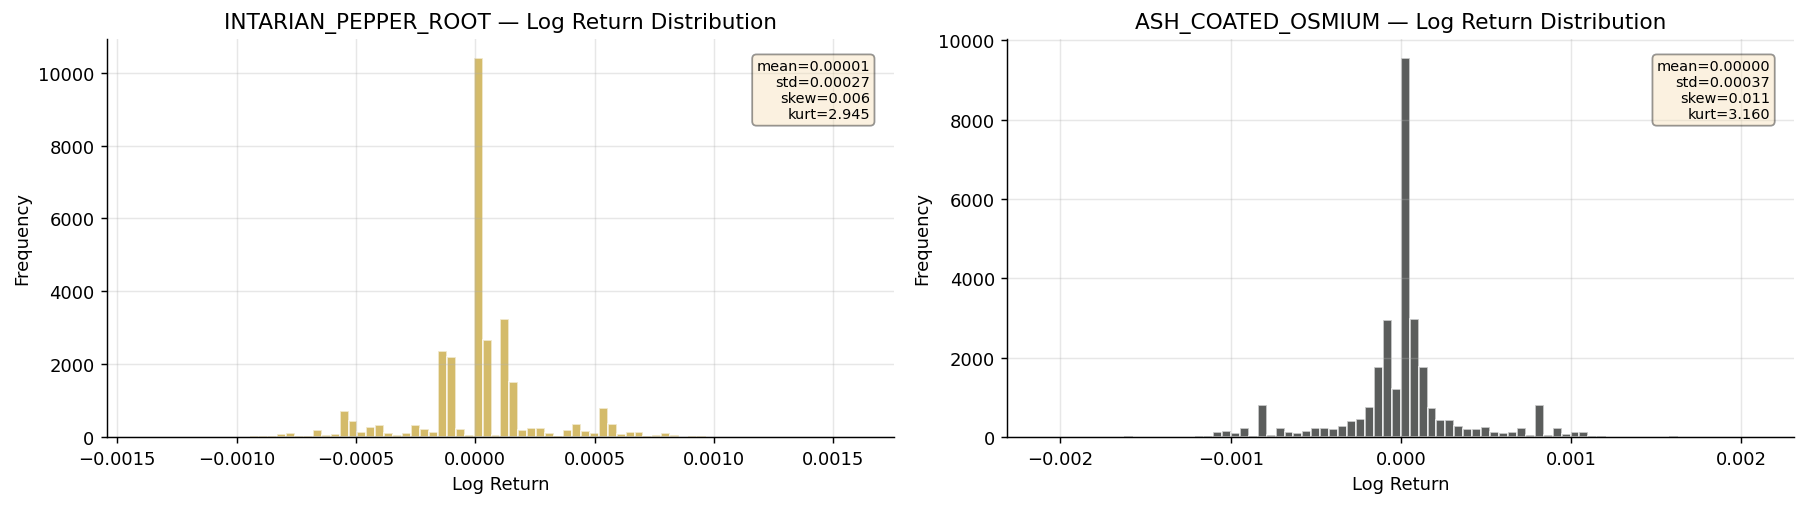

In [13]:
# ── Return distribution (log returns per tick) ───────────────────────────────
fig, axes = plt.subplots(1, len(PRODUCTS), figsize=(14, 4))
if len(PRODUCTS) == 1:
    axes = [axes]
    
for ax, prod in zip(axes, PRODUCTS):
    sub = prices[
        (prices['product'] == prod) &
        (prices['mid_price'] > 0)   # remove zeros
    ].copy()

    sub['log_ret'] = np.log(sub['mid_price']).diff()
    log_ret = sub['log_ret'].replace([np.inf, -np.inf], np.nan).dropna()

    log_ret.plot.hist(
        bins=80, ax=ax,
        color=COLORS.get(prod, 'steelblue'),
        alpha=0.7, edgecolor='white'
    )

    stats_txt = (
        f"mean={log_ret.mean():.5f}\n"
        f"std={log_ret.std():.5f}\n"
        f"skew={log_ret.skew():.3f}\n"
        f"kurt={log_ret.kurt():.3f}"
    )

    ax.text(0.97, 0.95, stats_txt, transform=ax.transAxes,
            va='top', ha='right', fontsize=8,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.4))

    ax.set_title(f'{prod} — Log Return Distribution')
    ax.set_xlabel('Log Return')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

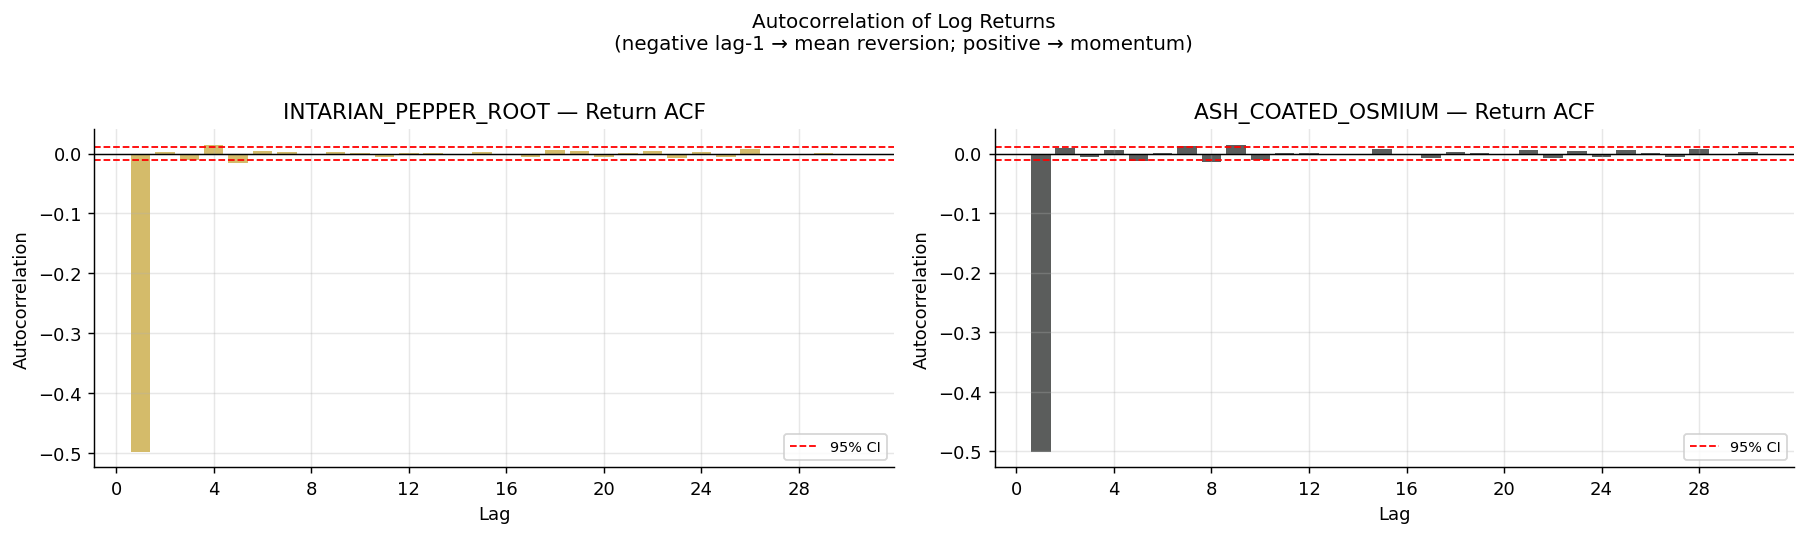

In [12]:
# ── Autocorrelation of returns (mean reversion / momentum check) ─────────────
from matplotlib.ticker import MaxNLocator

LAGS = 30
fig, axes = plt.subplots(1, len(PRODUCTS), figsize=(14, 4))
if len(PRODUCTS) == 1:
    axes = [axes]

for ax, prod in zip(axes, PRODUCTS):
    sub = prices[
        (prices['product'] == prod) &
        (prices['mid_price'] > 0)   # remove zeros (and negatives if any)
    ].copy()

    rets = np.log(sub['mid_price']).diff().dropna()

    acf = [rets.autocorr(lag=l) for l in range(1, LAGS+1)]
    conf = 1.96 / np.sqrt(len(rets))

    ax.bar(range(1, LAGS+1), acf,
           color=COLORS.get(prod, 'steelblue'), alpha=0.7)

    ax.axhline(conf,  color='red', linestyle='--', linewidth=1, label='95% CI')
    ax.axhline(-conf, color='red', linestyle='--', linewidth=1)
    ax.axhline(0, color='black', linewidth=0.8)

    ax.set_title(f'{prod} — Return ACF')
    ax.set_xlabel('Lag')
    ax.set_ylabel('Autocorrelation')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.suptitle('Autocorrelation of Log Returns\n(negative lag-1 → mean reversion; positive → momentum)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

## 3. Order Book Analysis

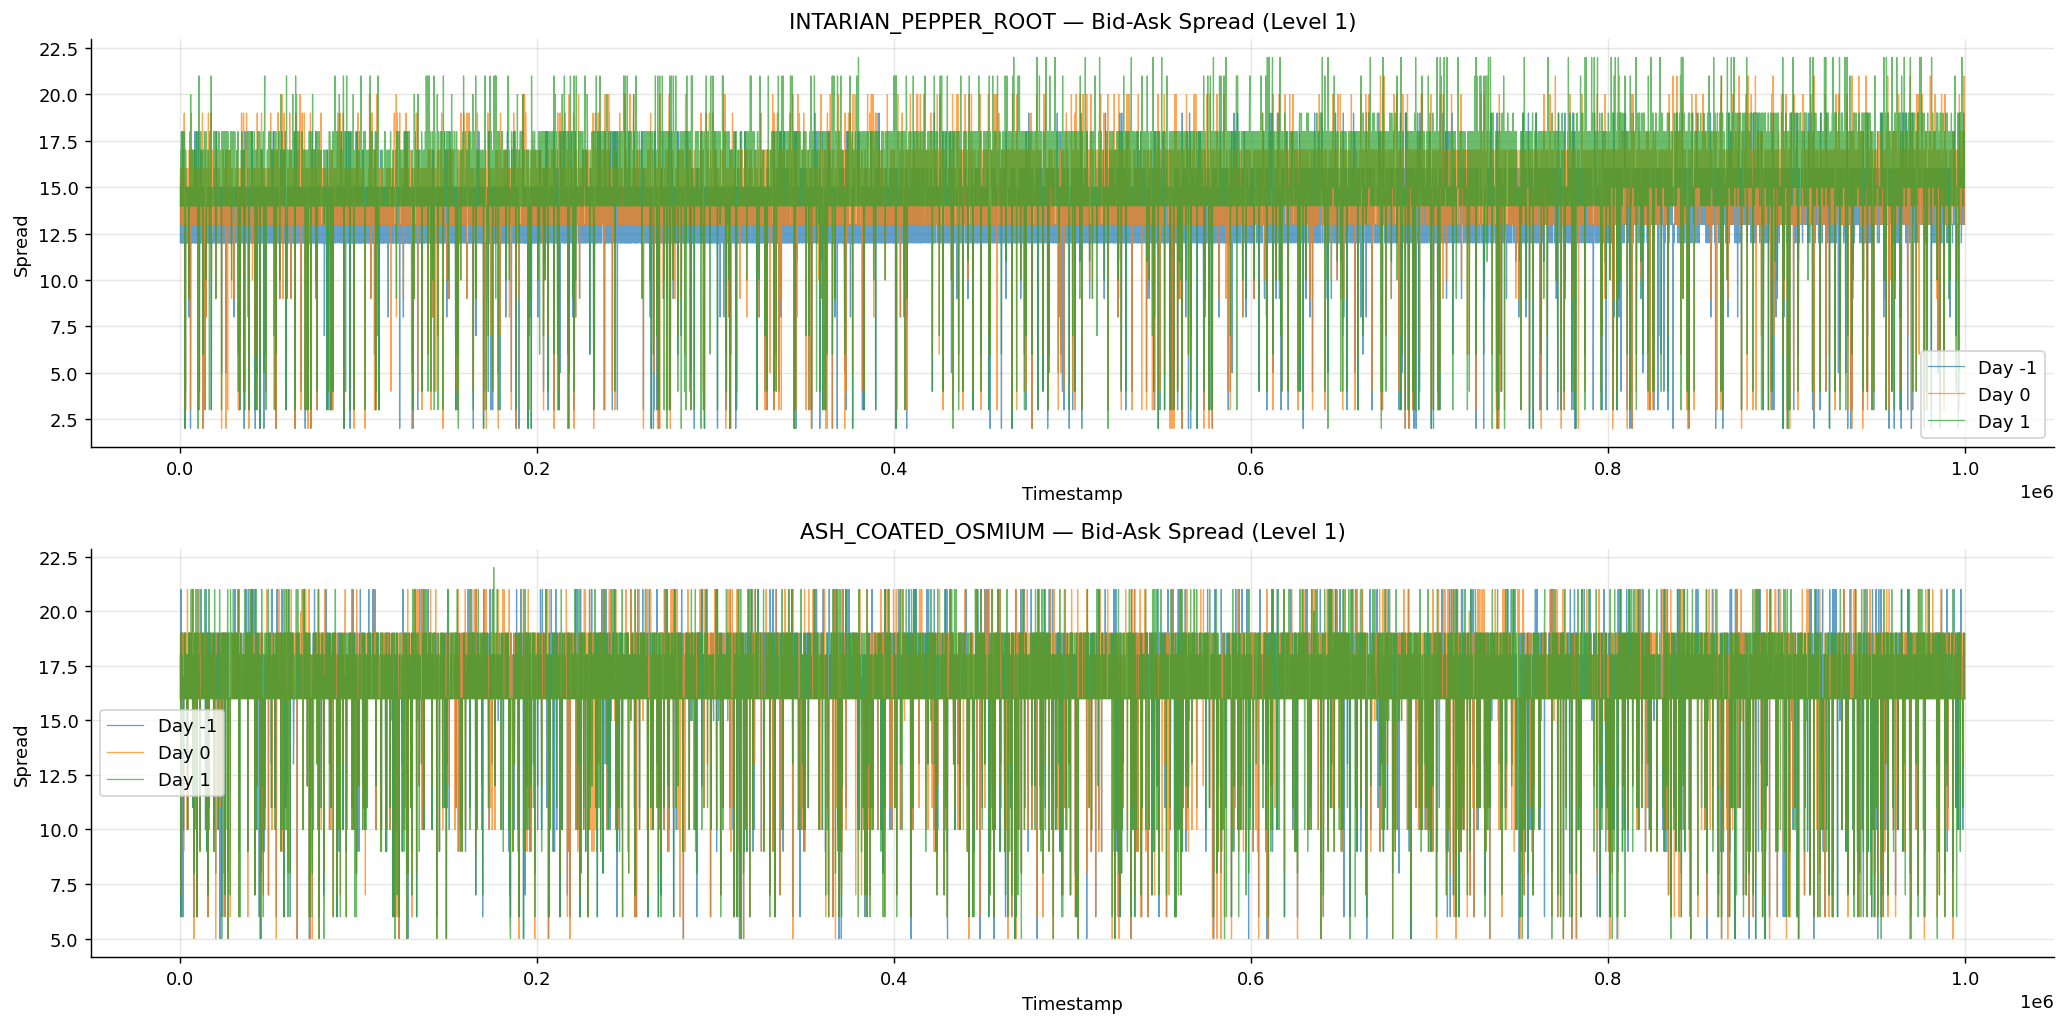


Spread distribution:
                        count    mean    std  min   25%   50%   75%   max
product                                                                  
ASH_COATED_OSMIUM     27708.0  16.234  2.520  5.0  16.0  16.0  18.0  22.0
INTARIAN_PEPPER_ROOT  27724.0  14.122  2.788  2.0  13.0  14.0  15.0  22.0


In [14]:
# ── Bid-ask spread over time ─────────────────────────────────────────────────
fig, axes = plt.subplots(len(PRODUCTS), 1, figsize=(16, 4*len(PRODUCTS)))
if len(PRODUCTS) == 1:
    axes = [axes]

for ax, prod in zip(axes, PRODUCTS):
    for day in DAYS:
        sub = prices[
            (prices['product'] == prod) &
            (prices['day'] == day) &
            (prices['ask_price_1'] > 0) &
            (prices['bid_price_1'] > 0)   # remove invalid quotes
        ].copy()

        sub['spread'] = sub['ask_price_1'] - sub['bid_price_1']

        ax.plot(sub['timestamp'], sub['spread'],
                alpha=0.7, linewidth=0.7, label=f'Day {day}')

    ax.set_title(f'{prod} — Bid-Ask Spread (Level 1)')
    ax.set_ylabel('Spread')
    ax.set_xlabel('Timestamp')
    ax.legend()

plt.tight_layout()
plt.show()

# Spread distribution per product
prices['spread_1'] = prices['ask_price_1'] - prices['bid_price_1']
print('\nSpread distribution:')
print(prices.groupby('product')['spread_1'].describe().round(3))

EMERALDS  OBI → next-tick return correlation: +0.6306
TOMATOES  OBI → next-tick return correlation: +0.3259


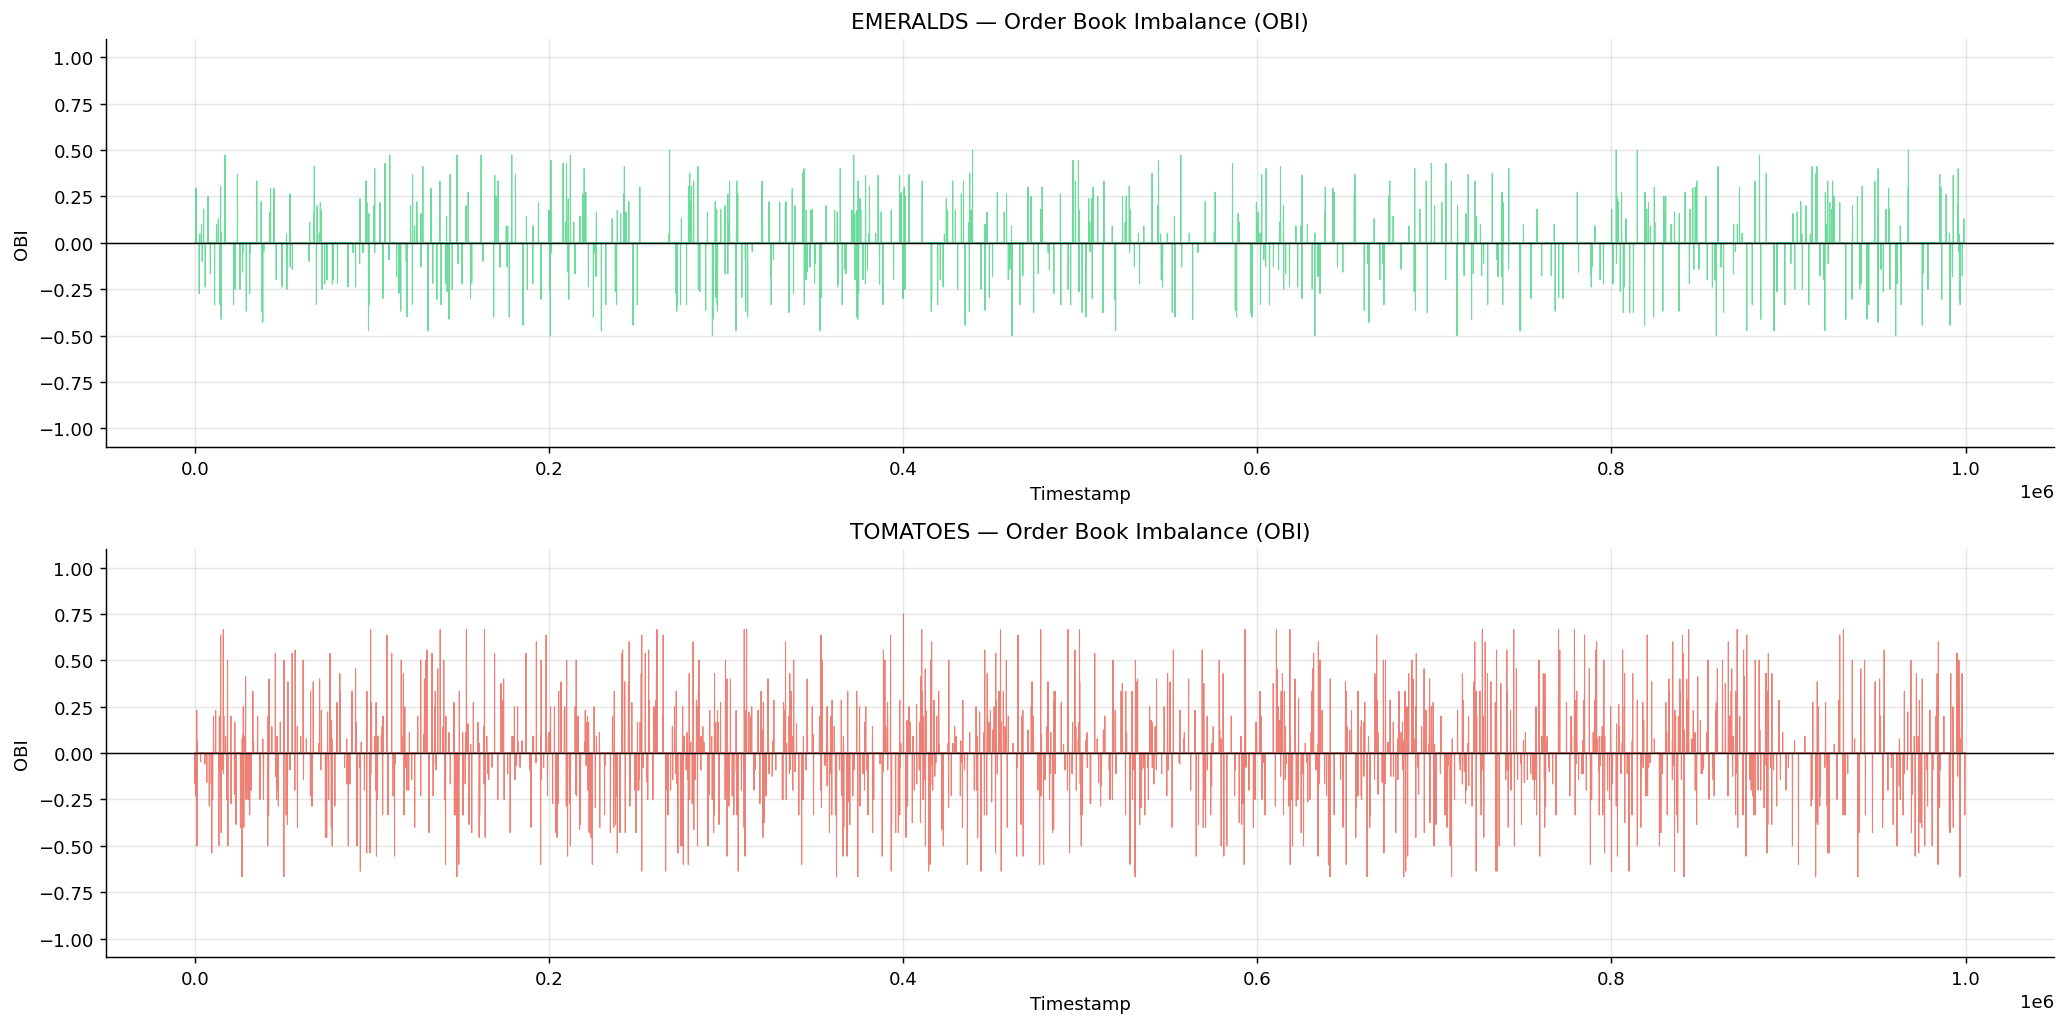

In [9]:
# ── Order Book Imbalance (OBI) — predictive signal ──────────────────────────
# OBI = (bid_vol_1 - ask_vol_1) / (bid_vol_1 + ask_vol_1)
# Positive OBI → more buy pressure → price likely to rise

prices['OBI'] = (
    (prices['bid_volume_1'] - prices['ask_volume_1']) /
    (prices['bid_volume_1'] + prices['ask_volume_1'])
)

# OBI → next mid-price return (forward 1 step per product)
obi_results = {}
for prod in PRODUCTS:
    sub = prices[prices['product'] == prod].copy().reset_index(drop=True)
    sub['fwd_ret'] = sub['mid_price'].shift(-1) / sub['mid_price'] - 1
    corr = sub[['OBI', 'fwd_ret']].dropna().corr().iloc[0, 1]
    obi_results[prod] = corr
    print(f'{prod}  OBI → next-tick return correlation: {corr:+.4f}')

# Plot OBI
fig, axes = plt.subplots(len(PRODUCTS), 1, figsize=(16, 4*len(PRODUCTS)))
if len(PRODUCTS) == 1:
    axes = [axes]

for ax, prod in zip(axes, PRODUCTS):
    sub = prices[prices['product'] == prod]
    ax.plot(sub['timestamp'], sub['OBI'], color=COLORS.get(prod, 'steelblue'),
            linewidth=0.6, alpha=0.7)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f'{prod} — Order Book Imbalance (OBI)')
    ax.set_ylabel('OBI')
    ax.set_xlabel('Timestamp')
    ax.set_ylim(-1.1, 1.1)

plt.tight_layout()
plt.show()

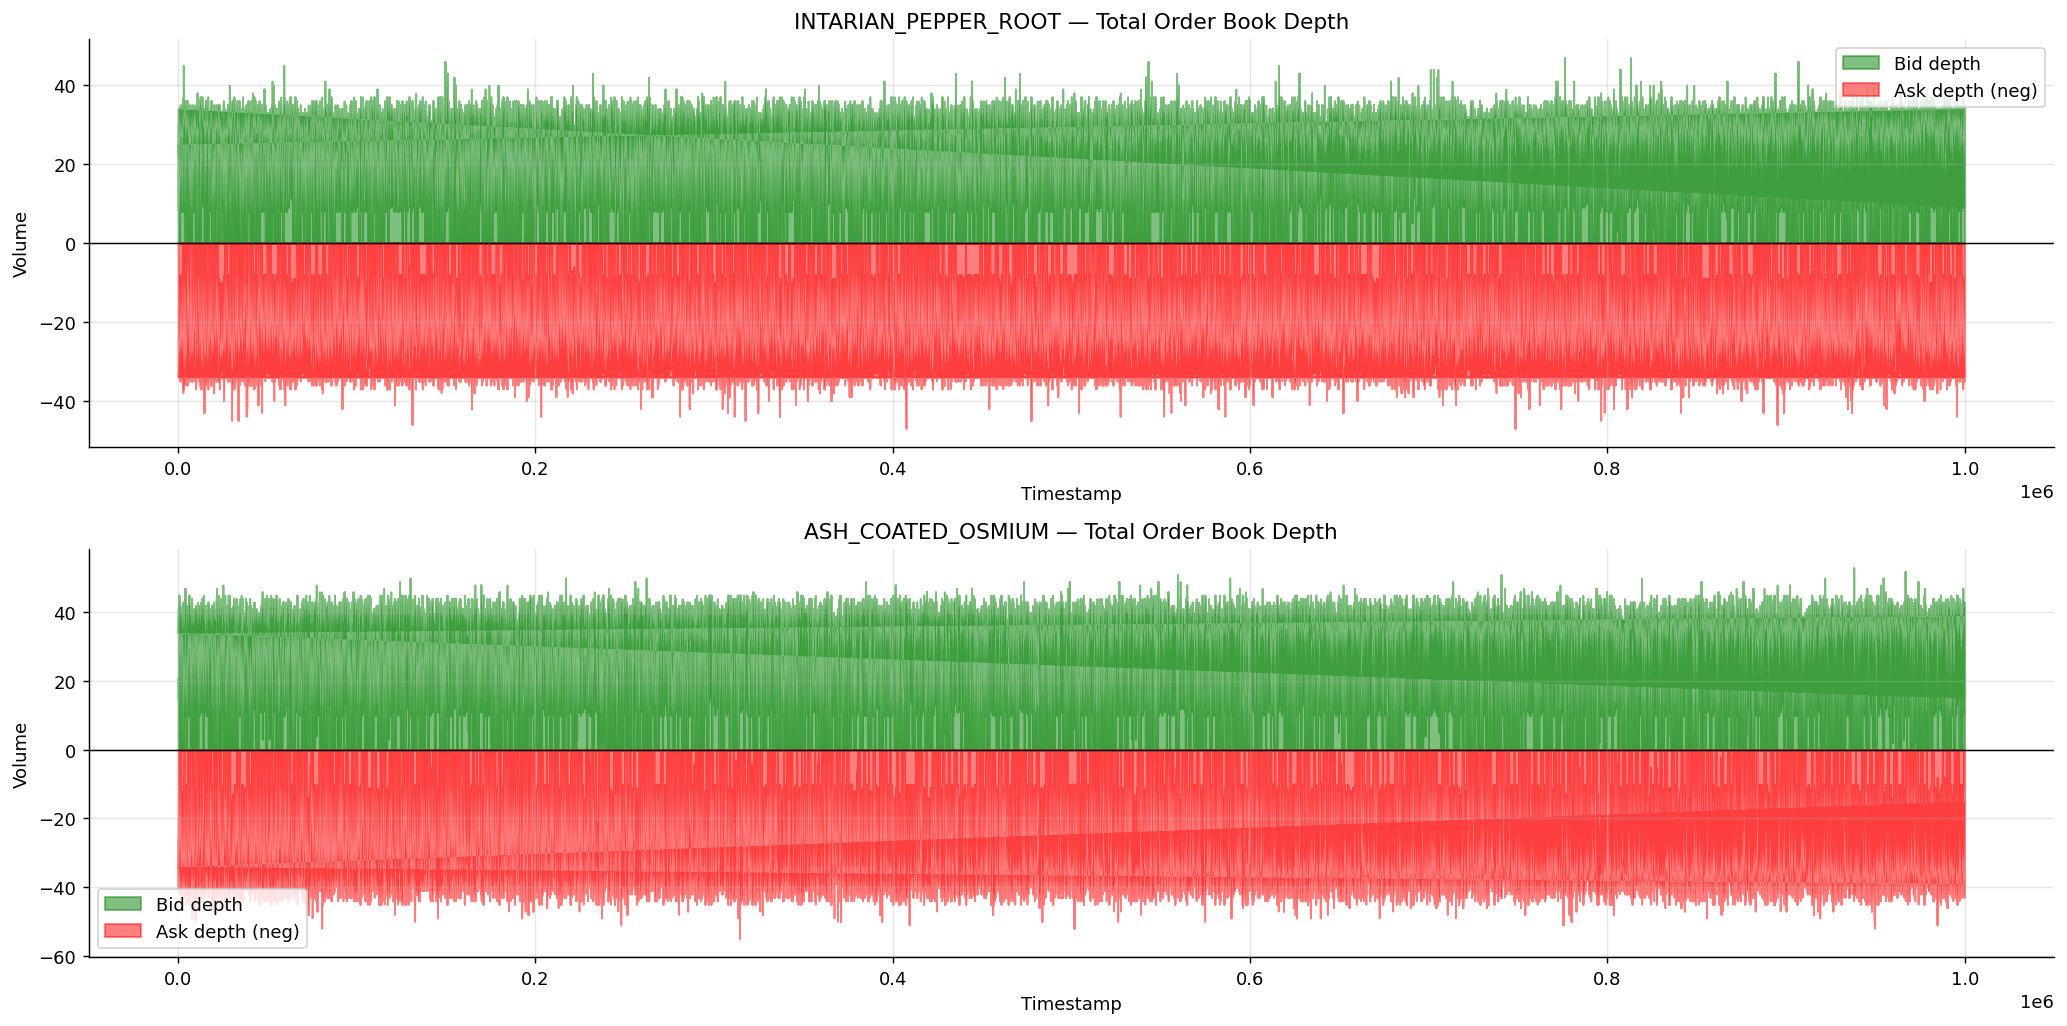

In [15]:
# ── Total order book depth (all levels) ─────────────────────────────────────
bid_vol_cols = ['bid_volume_1', 'bid_volume_2', 'bid_volume_3']
ask_vol_cols = ['ask_volume_1', 'ask_volume_2', 'ask_volume_3']

prices['total_bid_depth'] = prices[bid_vol_cols].sum(axis=1, skipna=True)
prices['total_ask_depth'] = prices[ask_vol_cols].sum(axis=1, skipna=True)

fig, axes = plt.subplots(len(PRODUCTS), 1, figsize=(16, 4*len(PRODUCTS)))
if len(PRODUCTS) == 1:
    axes = [axes]

for ax, prod in zip(axes, PRODUCTS):
    sub = prices[prices['product'] == prod]
    ax.fill_between(sub['timestamp'], sub['total_bid_depth'],
                    alpha=0.5, label='Bid depth', color='green')
    ax.fill_between(sub['timestamp'], -sub['total_ask_depth'],
                    alpha=0.5, label='Ask depth (neg)', color='red')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f'{prod} — Total Order Book Depth')
    ax.set_ylabel('Volume')
    ax.set_xlabel('Timestamp')
    ax.legend()

plt.tight_layout()
plt.show()

## 4. Trade Flow Analysis

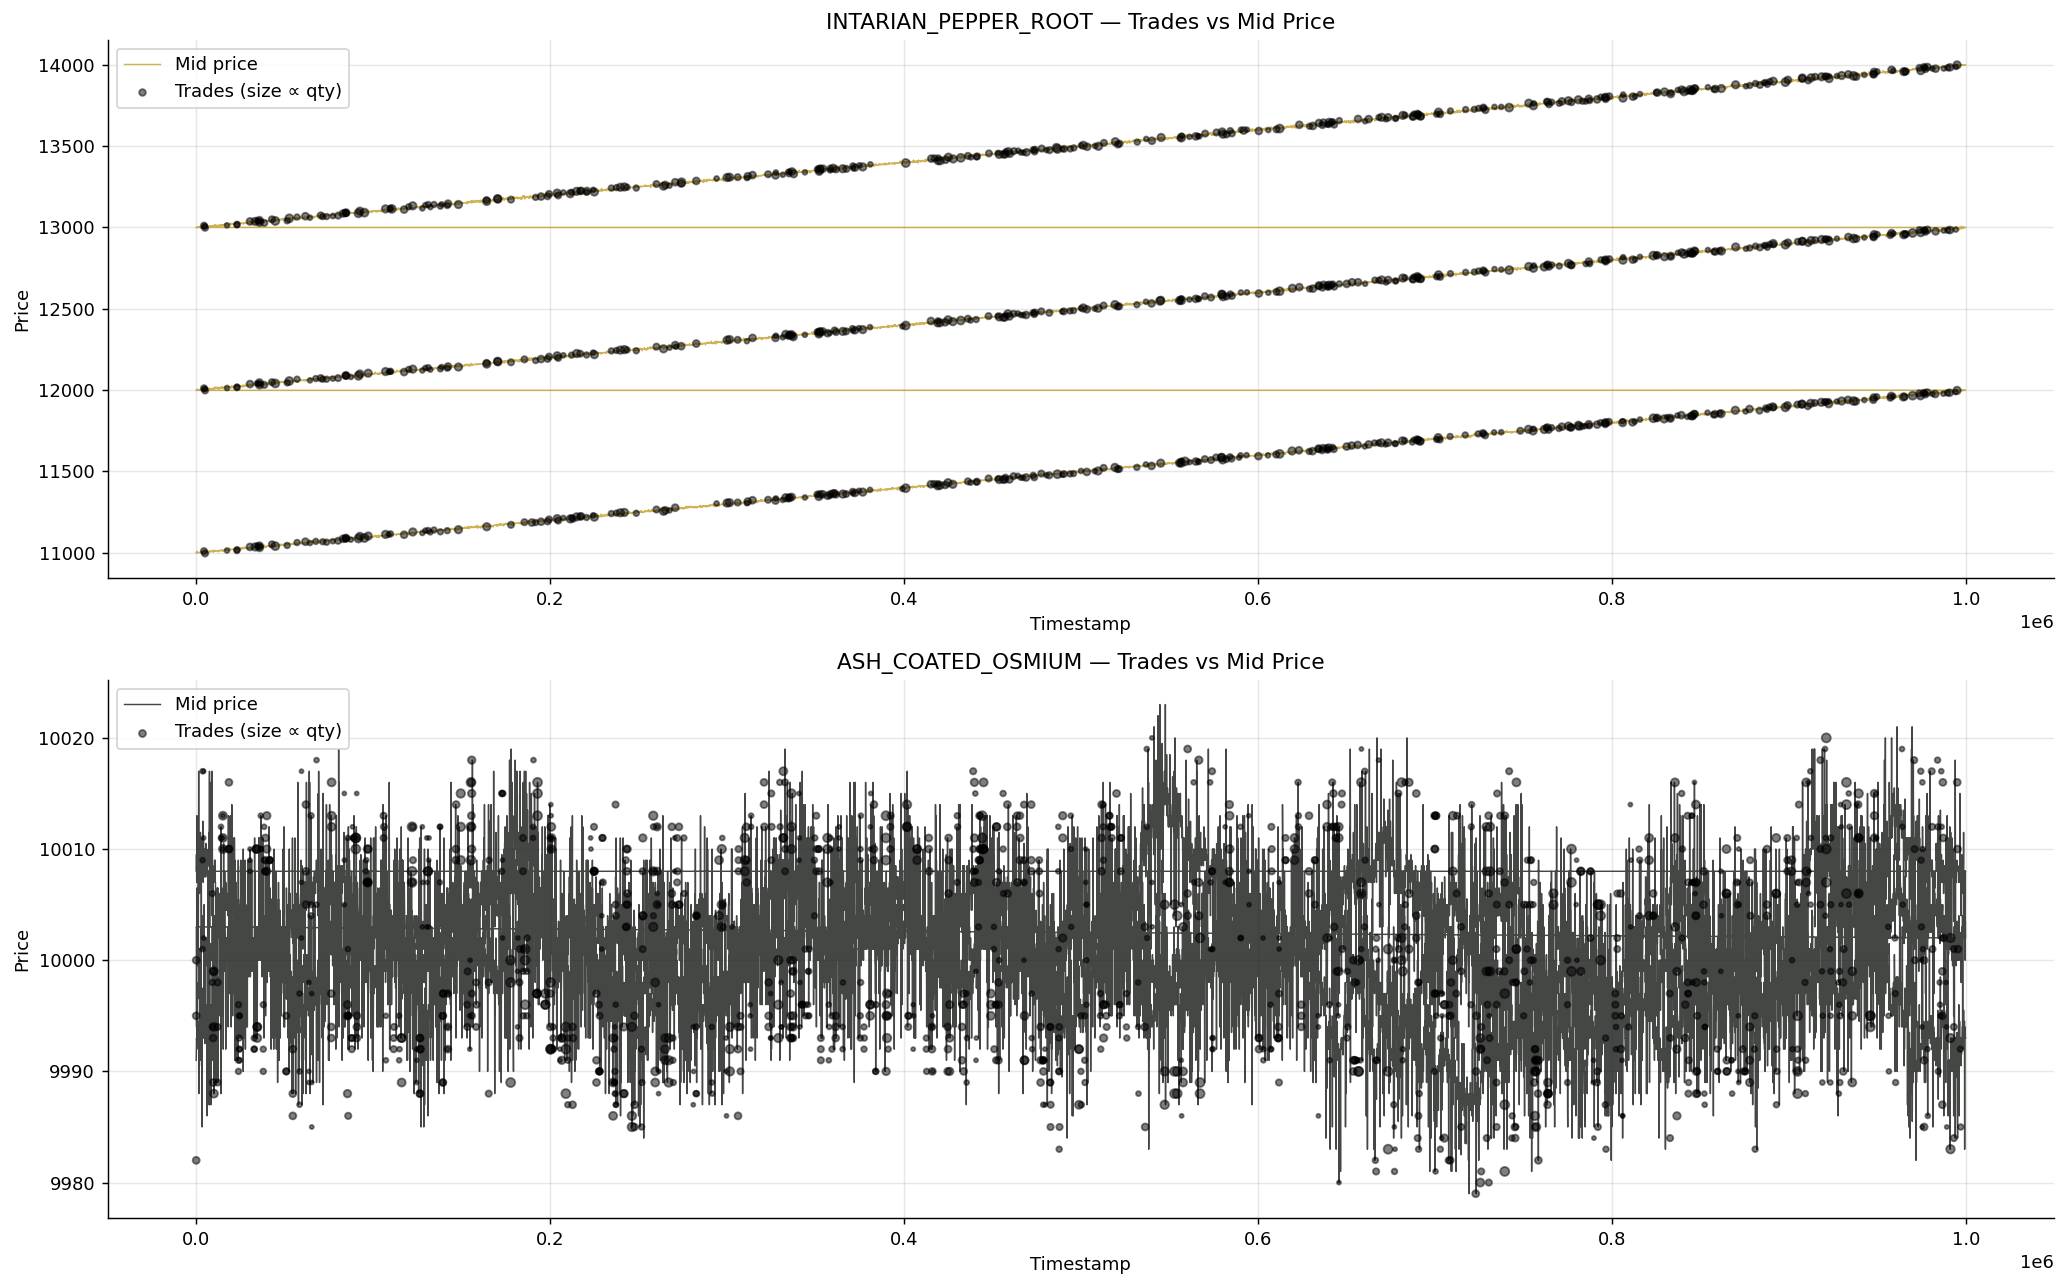

In [17]:
# ── Trade price vs. mid-price ────────────────────────────────────────────────
fig, axes = plt.subplots(len(PRODUCTS), 1, figsize=(16, 5*len(PRODUCTS)))
if len(PRODUCTS) == 1:
    axes = [axes]

for ax, prod in zip(axes, PRODUCTS):
    mid = prices[
        (prices['product'] == prod) &
        (prices['mid_price'] > 0)   # remove zero mid prices
    ][['timestamp', 'mid_price']].copy()

    tr = trades[
        (trades['product'] == prod) &
        (trades['price'] > 0) &      # remove zero trade prices
        (trades['quantity'] > 0)     # optional: remove zero-size trades
    ].copy()

    ax.plot(mid['timestamp'], mid['mid_price'],
            color=COLORS.get(prod, 'steelblue'),
            linewidth=0.8, alpha=0.8, label='Mid price')

    ax.scatter(tr['timestamp'], tr['price'],
               s=tr['quantity'] * 2.5,
               color='black', alpha=0.5, zorder=5,
               label='Trades (size ∝ qty)')

    ax.set_title(f'{prod} — Trades vs Mid Price')
    ax.set_ylabel('Price')
    ax.set_xlabel('Timestamp')
    ax.legend()

plt.tight_layout()
plt.show()

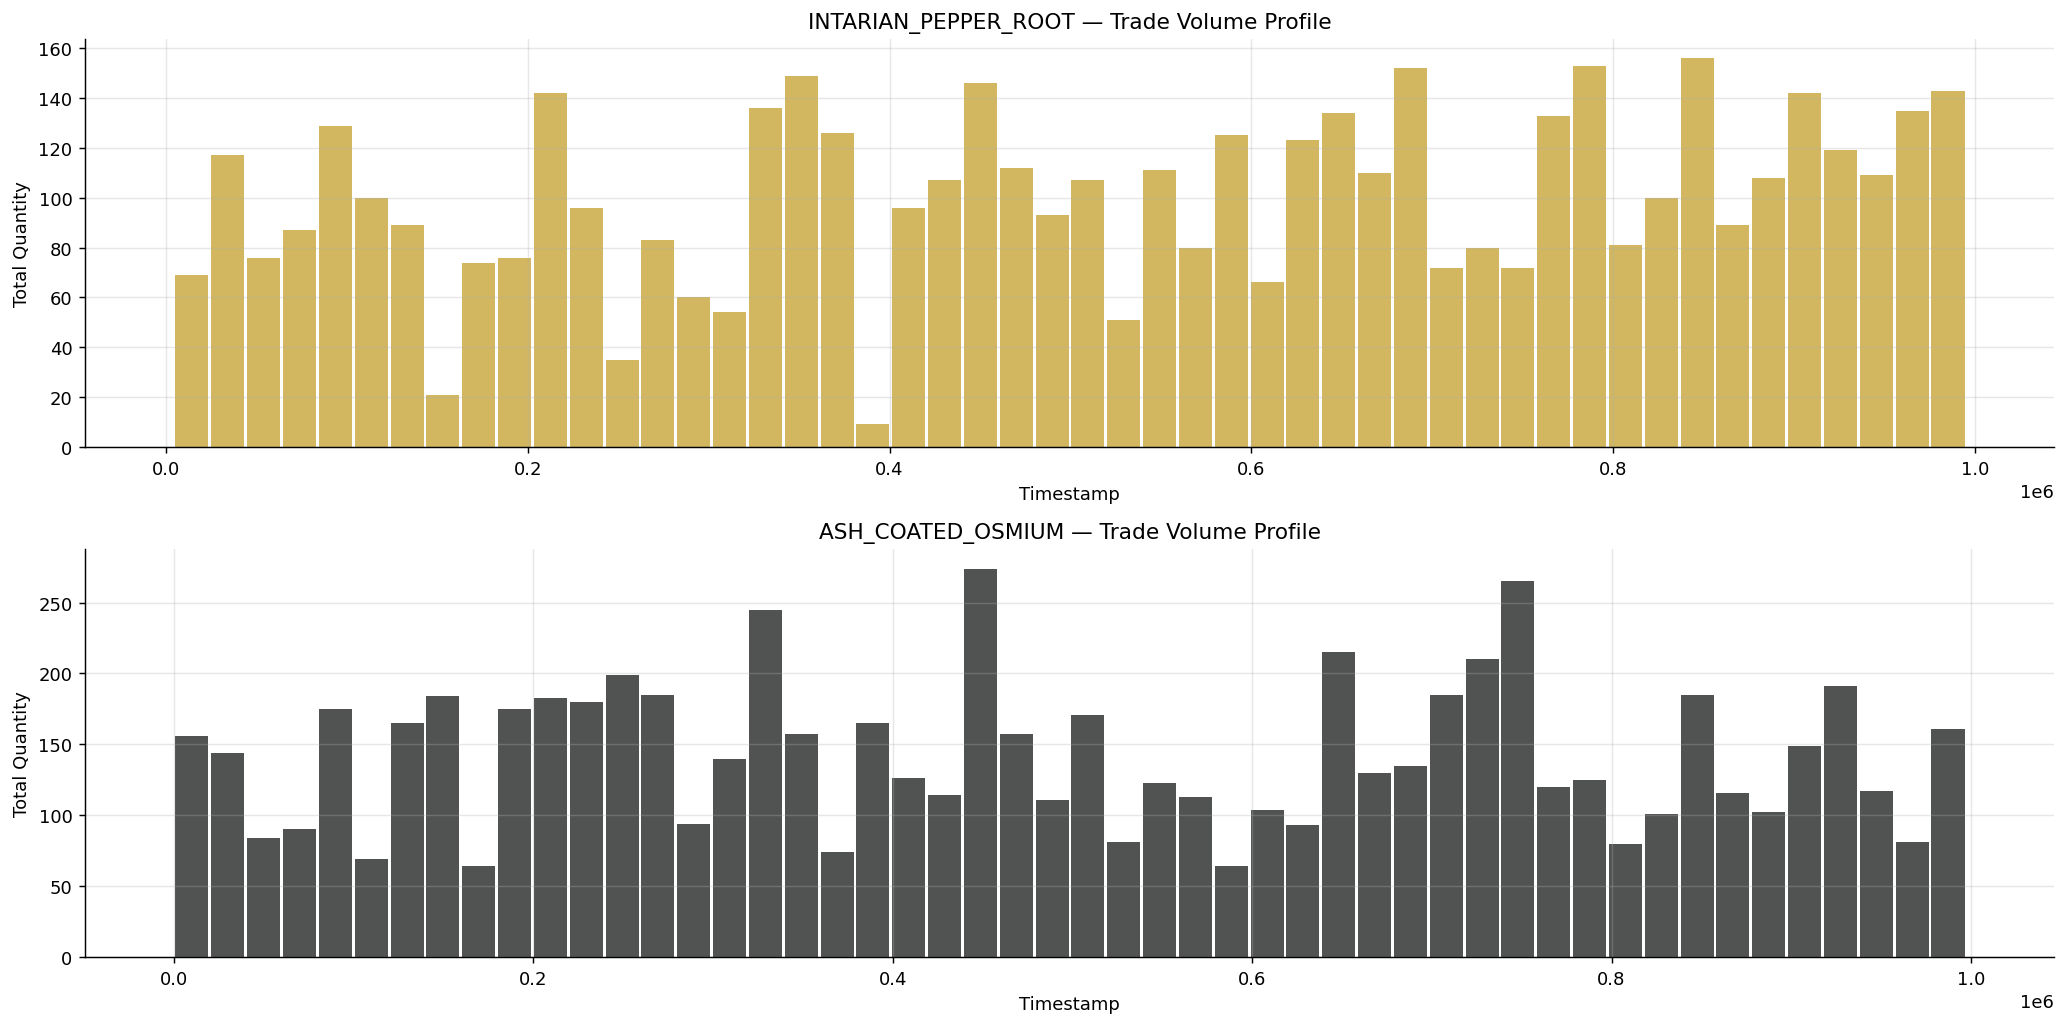

In [18]:
# ── Trade volume profile (bucket into 50 time bins) ──────────────────────────
fig, axes = plt.subplots(len(PRODUCTS), 1, figsize=(16, 4*len(PRODUCTS)))
if len(PRODUCTS) == 1:
    axes = [axes]

for ax, prod in zip(axes, PRODUCTS):
    tr = trades[trades['product'] == prod].copy()
    tr['bin'] = pd.cut(tr['timestamp'], bins=50)
    vol = tr.groupby('bin', observed=True)['quantity'].sum()
    vol.index = vol.index.map(lambda x: x.mid)
    ax.bar(vol.index, vol.values, width=(vol.index[1]-vol.index[0])*0.9,
           color=COLORS.get(prod, 'steelblue'), alpha=0.75)
    ax.set_title(f'{prod} — Trade Volume Profile')
    ax.set_ylabel('Total Quantity')
    ax.set_xlabel('Timestamp')

plt.tight_layout()
plt.show()

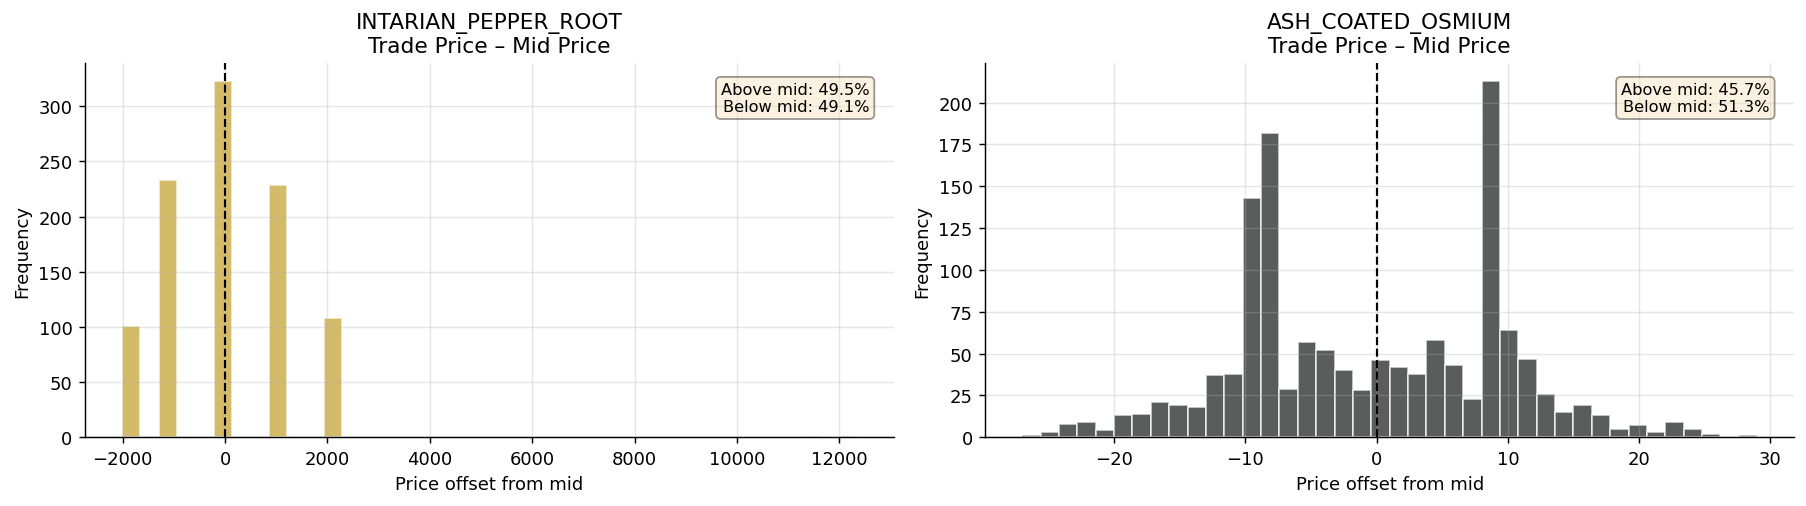

In [19]:
# ── Trade price relative to mid (execution quality / aggressor direction) ────
# Merge each trade with nearest prior mid-price

results = []
for prod in PRODUCTS:
    mid = prices[prices['product'] == prod][['timestamp', 'mid_price']].copy()
    tr  = trades[trades['product'] == prod].copy()
    merged = pd.merge_asof(
        tr.sort_values('timestamp'),
        mid.sort_values('timestamp'),
        on='timestamp', direction='backward'
    )
    merged['rel_price'] = merged['price'] - merged['mid_price']
    merged['direction'] = np.where(merged['rel_price'] > 0, 'Buy (above mid)', 'Sell (below mid)')
    merged['product'] = prod
    results.append(merged)

trade_enriched = pd.concat(results)

fig, axes = plt.subplots(1, len(PRODUCTS), figsize=(14, 4))
if len(PRODUCTS) == 1:
    axes = [axes]

for ax, prod in zip(axes, PRODUCTS):
    sub = trade_enriched[trade_enriched['product'] == prod]
    sub['rel_price'].plot.hist(bins=40, ax=ax,
                               color=COLORS.get(prod, 'steelblue'), alpha=0.7, edgecolor='white')
    ax.axvline(0, color='black', linewidth=1.2, linestyle='--')
    ax.set_title(f'{prod}\nTrade Price – Mid Price')
    ax.set_xlabel('Price offset from mid')
    buys  = (sub['rel_price'] > 0).mean() * 100
    sells = (sub['rel_price'] < 0).mean() * 100
    ax.text(0.97, 0.95, f'Above mid: {buys:.1f}%\nBelow mid: {sells:.1f}%',
            transform=ax.transAxes, va='top', ha='right', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.4))

plt.tight_layout()
plt.show()

## 5. Fair Value Estimation

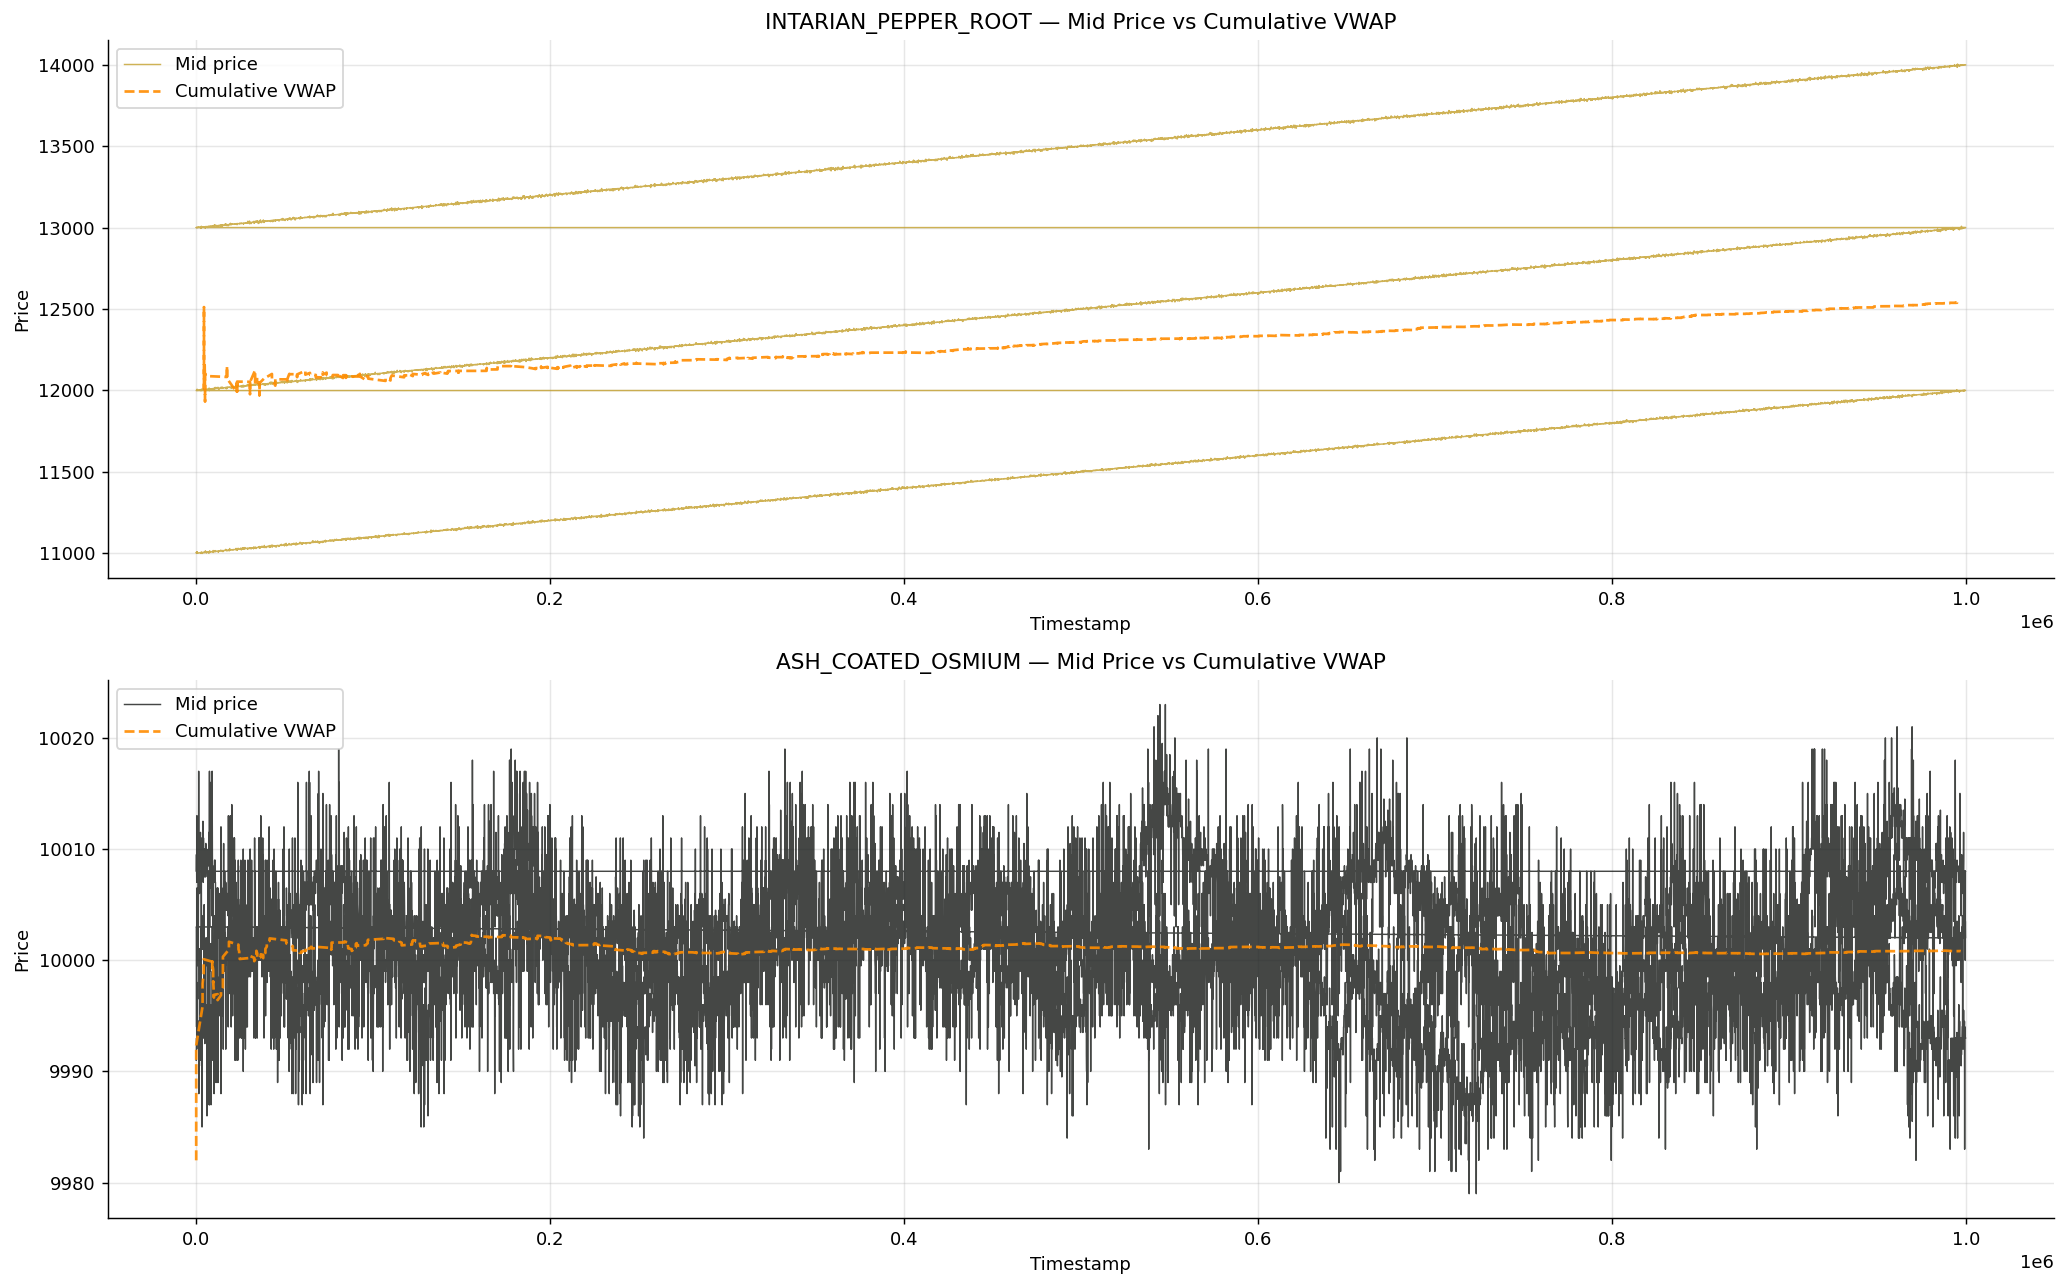

In [21]:
# ── Volume-Weighted Average Price (VWAP) per rolling window ──────────────────
WINDOW = 100  # ticks

# Merge trades onto price grid
vwap_results = []
for prod in PRODUCTS:
    tr = trades[trades['product'] == prod].copy()
    tr['pq'] = tr['price'] * tr['quantity']
    tr['cum_pq'] = tr['pq'].cumsum()
    tr['cum_q']  = tr['quantity'].cumsum()
    tr['vwap']   = tr['cum_pq'] / tr['cum_q']
    tr['product'] = prod
    vwap_results.append(tr)

vwap_df = pd.concat(vwap_results)

fig, axes = plt.subplots(len(PRODUCTS), 1, figsize=(16, 5*len(PRODUCTS)))
if len(PRODUCTS) == 1:
    axes = [axes]

for ax, prod in zip(axes, PRODUCTS):
    mid = prices[
        (prices['product'] == prod) &
        (prices['mid_price'] > 0)   # remove zero mid prices
    ][['timestamp', 'mid_price']].copy()

    tr = vwap_df[
        (vwap_df['product'] == prod) &
        (vwap_df['vwap'] > 0)       # remove zero VWAP
    ][['timestamp', 'vwap']].copy()

    # Optional safety if upstream data is messy
    mid = mid.replace([np.inf, -np.inf], np.nan).dropna()
    tr  = tr.replace([np.inf, -np.inf], np.nan).dropna()

    ax.plot(mid['timestamp'], mid['mid_price'],
            color=COLORS.get(prod, 'steelblue'),
            linewidth=0.8, alpha=0.8, label='Mid price')

    ax.plot(tr['timestamp'], tr['vwap'],
            color='darkorange',
            linewidth=1.5, linestyle='--',
            alpha=0.9, label='Cumulative VWAP')

    ax.set_title(f'{prod} — Mid Price vs Cumulative VWAP')
    ax.set_ylabel('Price')
    ax.set_xlabel('Timestamp')
    ax.legend()

plt.tight_layout()
plt.show()

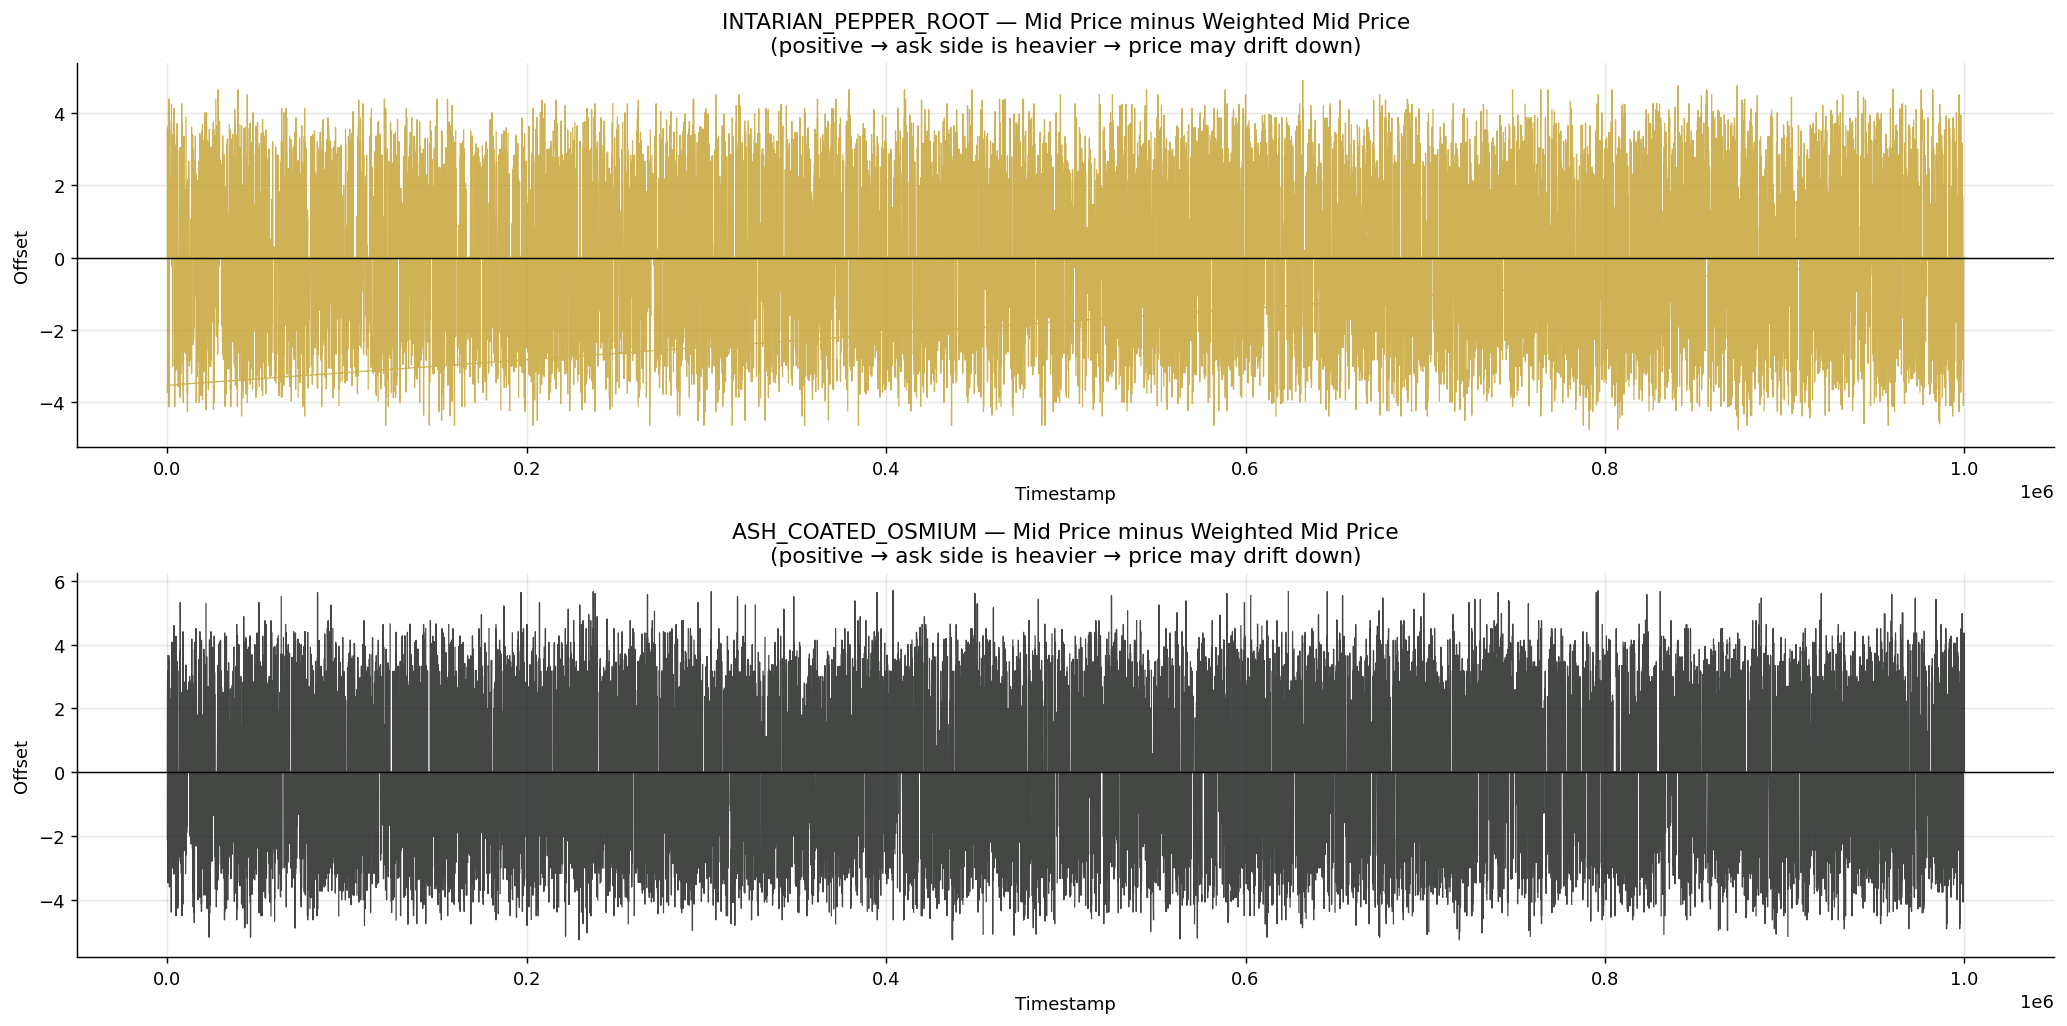

In [22]:
# ── Weighted Mid Price (accounts for order book pressure) ────────────────────
# Weighted mid = (ask_price_1 × bid_vol_1 + bid_price_1 × ask_vol_1) / (bid_vol_1 + ask_vol_1)

prices['weighted_mid'] = (
    prices['ask_price_1'] * prices['bid_volume_1'] +
    prices['bid_price_1'] * prices['ask_volume_1']
) / (prices['bid_volume_1'] + prices['ask_volume_1'])

prices['mid_vs_wmid'] = prices['mid_price'] - prices['weighted_mid']

fig, axes = plt.subplots(len(PRODUCTS), 1, figsize=(16, 4*len(PRODUCTS)))
if len(PRODUCTS) == 1:
    axes = [axes]

for ax, prod in zip(axes, PRODUCTS):
    sub = prices[prices['product'] == prod]
    ax.plot(sub['timestamp'], sub['mid_vs_wmid'],
            color=COLORS.get(prod, 'steelblue'), linewidth=0.7, alpha=0.8)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f'{prod} — Mid Price minus Weighted Mid Price\n'
                 f'(positive → ask side is heavier → price may drift down)')
    ax.set_ylabel('Offset')
    ax.set_xlabel('Timestamp')

plt.tight_layout()
plt.show()

## 6. Market-Making Metrics

In [23]:
# ── Optimal quoting spread analysis ─────────────────────────────────────────
# Key question: what spread should we quote to earn the spread while
# not getting adversely selected?

for prod in PRODUCTS:
    p = prices[prices['product'] == prod].copy()
    t = trades[trades['product'] == prod].copy()

    # Observed market spread (level 1)
    p['spread'] = p['ask_price_1'] - p['bid_price_1']
    mean_spread  = p['spread'].mean()
    mode_spread  = p['spread'].mode()[0]

    # Realized volatility (std of log returns per tick)
    log_ret = np.log(p['mid_price']).diff().dropna()
    rv = log_ret.std() * np.sqrt(len(log_ret))  # per-day vol estimate

    # Trade frequency
    n_trades = len(t)
    ts_range  = p['timestamp'].max() - p['timestamp'].min()
    trade_freq = n_trades / (ts_range / 100)  # trades per 100-unit interval

    print(f"\n{'='*50}")
    print(f'  {prod}')
    print(f"{'='*50}")
    print(f'  Mean market spread  : {mean_spread:.2f}')
    print(f'  Mode market spread  : {mode_spread}')
    print(f'  Tick-level vol (std): {log_ret.std()*10000:.4f} bps')
    print(f'  Daily realized vol  : {rv:.4f}')
    print(f'  Trade freq (per 100 ts): {trade_freq:.4f}')
    print(f'  → Suggested quote spread: {mean_spread * 0.9:.2f} – {mean_spread:.2f}')
    print(f'    (quote inside market to attract flow, but not too tight)')


  INTARIAN_PEPPER_ROOT
  Mean market spread  : 14.12
  Mode market spread  : 14.0
  Tick-level vol (std): nan bps
  Daily realized vol  : nan
  Trade freq (per 100 ts): 0.0996
  → Suggested quote spread: 12.71 – 14.12
    (quote inside market to attract flow, but not too tight)

  ASH_COATED_OSMIUM
  Mean market spread  : 16.23
  Mode market spread  : 16.0
  Tick-level vol (std): nan bps
  Daily realized vol  : nan
  Trade freq (per 100 ts): 0.1395
  → Suggested quote spread: 14.61 – 16.23
    (quote inside market to attract flow, but not too tight)


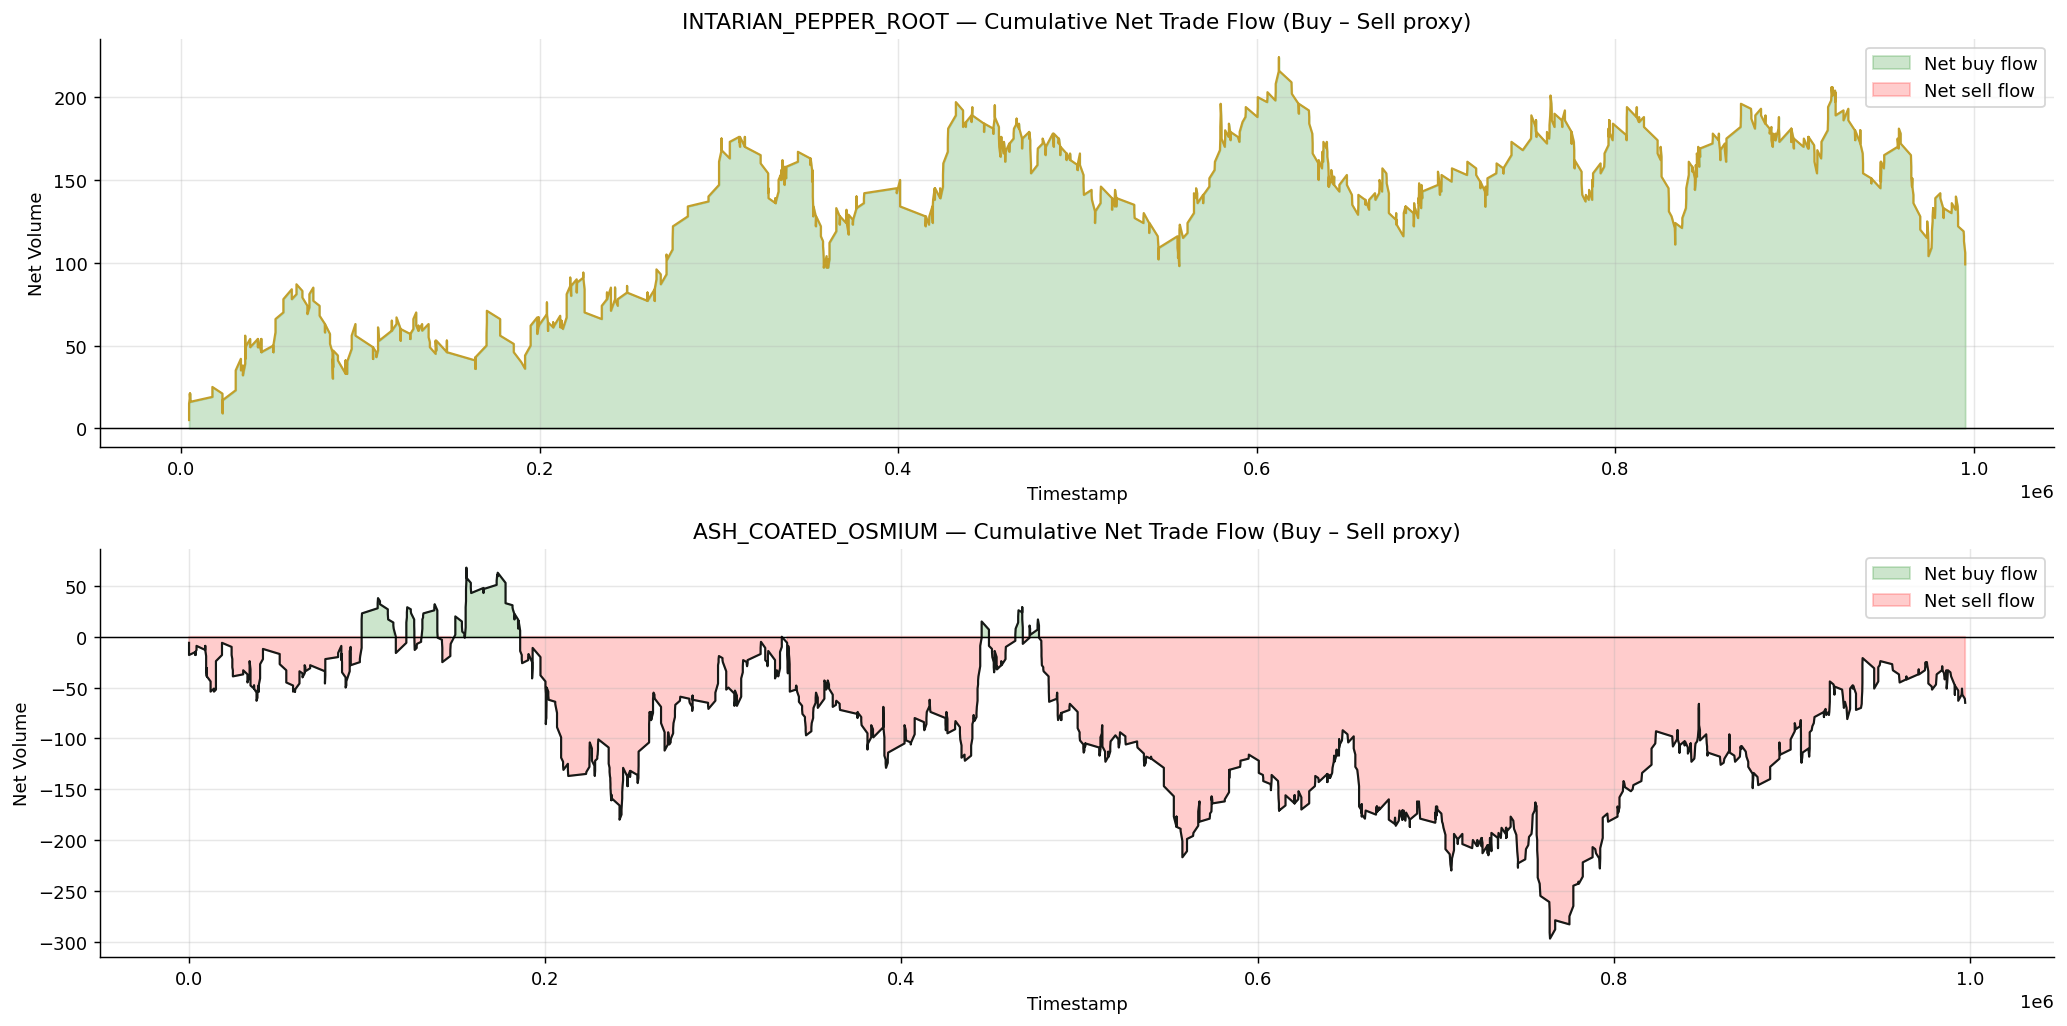

In [24]:
# ── Trade imbalance as inventory risk proxy ──────────────────────────────────
# Net volume (buy - sell) over time — proxy for inventory build-up
# Since buyer/seller columns are NaN, we use price vs mid to infer direction

fig, axes = plt.subplots(len(PRODUCTS), 1, figsize=(16, 4*len(PRODUCTS)))
if len(PRODUCTS) == 1:
    axes = [axes]

for ax, prod in zip(axes, PRODUCTS):
    sub = trade_enriched[trade_enriched['product'] == prod].copy()
    sub['signed_qty'] = np.where(sub['rel_price'] >= 0,
                                  sub['quantity'], -sub['quantity'])
    sub = sub.sort_values('timestamp')
    sub['cumulative_flow'] = sub['signed_qty'].cumsum()
    ax.plot(sub['timestamp'], sub['cumulative_flow'],
            color=COLORS.get(prod, 'steelblue'), linewidth=1.2)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.fill_between(sub['timestamp'], sub['cumulative_flow'], 0,
                    where=(sub['cumulative_flow'] > 0),
                    alpha=0.2, color='green', label='Net buy flow')
    ax.fill_between(sub['timestamp'], sub['cumulative_flow'], 0,
                    where=(sub['cumulative_flow'] < 0),
                    alpha=0.2, color='red', label='Net sell flow')
    ax.set_title(f'{prod} — Cumulative Net Trade Flow (Buy – Sell proxy)')
    ax.set_ylabel('Net Volume')
    ax.set_xlabel('Timestamp')
    ax.legend()

plt.tight_layout()
plt.show()

## 7. Cross-Product Correlation

Return Correlation Matrix:
product               ASH_COATED_OSMIUM  INTARIAN_PEPPER_ROOT
product                                                      
ASH_COATED_OSMIUM                1.0000               -0.0191
INTARIAN_PEPPER_ROOT            -0.0191                1.0000


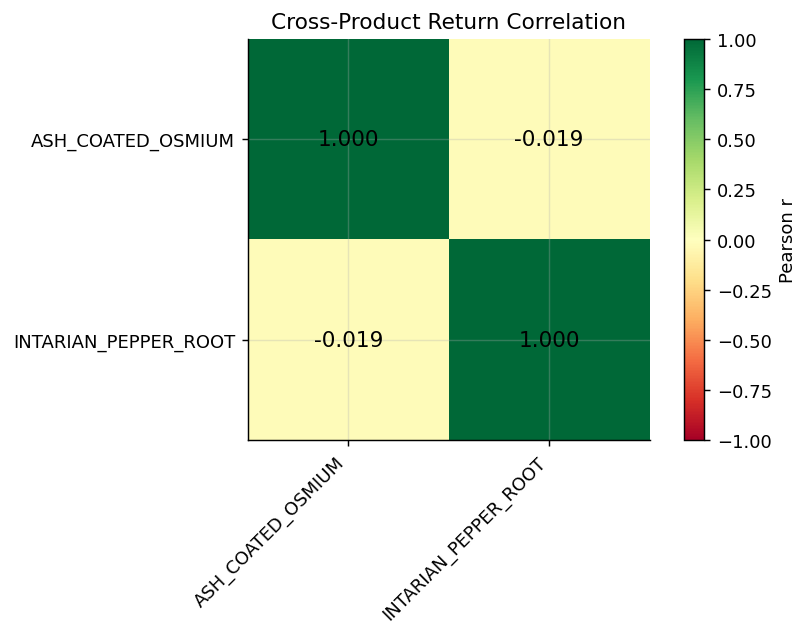

In [25]:
# ── Cross-product return correlation ─────────────────────────────────────────
# Pivot mid-prices and compute correlation

pivot = prices.pivot_table(index='timestamp', columns='product', values='mid_price')
log_rets = np.log(pivot).diff().dropna()

print('Return Correlation Matrix:')
print(log_rets.corr().round(4))

fig, ax = plt.subplots(figsize=(7, 5))
corr = log_rets.corr()
im = ax.imshow(corr.values, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label='Pearson r')
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.index)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.values[i,j]:.3f}', ha='center', va='center', fontsize=12)
ax.set_title('Cross-Product Return Correlation')
plt.tight_layout()
plt.show()

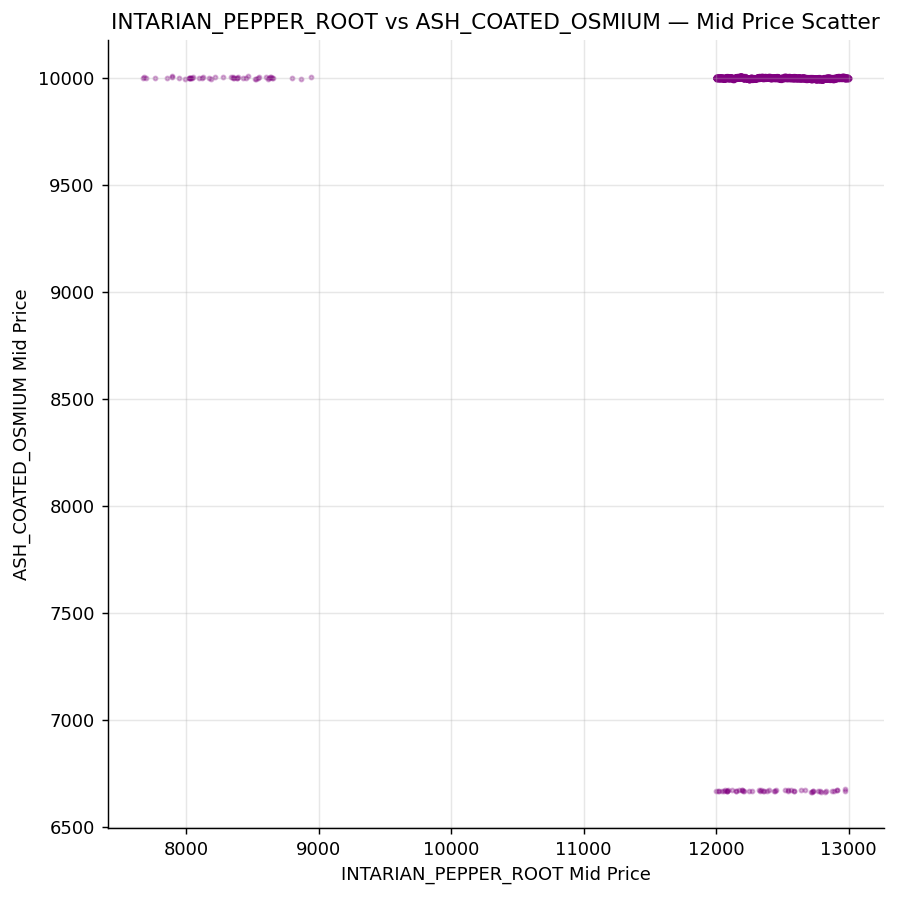

In [26]:
# ── Mid-price scatter: do they co-move? ──────────────────────────────────────
if len(PRODUCTS) >= 2:
    pivot_clean = pivot.dropna()
    p1, p2 = PRODUCTS[0], PRODUCTS[1]

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.scatter(pivot_clean[p1], pivot_clean[p2], alpha=0.3, s=5,
               color='purple')
    ax.set_xlabel(f'{p1} Mid Price')
    ax.set_ylabel(f'{p2} Mid Price')
    ax.set_title(f'{p1} vs {p2} — Mid Price Scatter')
    plt.tight_layout()
    plt.show()
else:
    print('Only one product — skipping scatter.')

## 8. Actionable Signal Summary

In [28]:
# ── Signal summary dashboard ─────────────────────────────────────────────────

print('=' * 65)
print('  SIGNAL SUMMARY — IMC Prosperity 4')
print('=' * 65)

for prod in PRODUCTS:
    p = prices[prices['product'] == prod].copy()
    t = trades[trades['product'] == prod].copy()
    te = trade_enriched[trade_enriched['product'] == prod].copy()

    p['spread'] = p['ask_price_1'] - p['bid_price_1']
    log_ret = np.log(p['mid_price']).diff().dropna()
    obi_corr = p[['OBI']].join(
        (p['mid_price'].shift(-1) / p['mid_price'] - 1).rename('fwd')
    ).dropna().corr().iloc[0, 1]
    autocorr_lag1 = log_ret.autocorr(lag=1)

    print(f'\n  [{prod}]')
    print(f'  Mid price (mean):       {p["mid_price"].mean():.2f}')
    print(f'  Mid price (std):        {p["mid_price"].std():.4f}')
    print(f'  Spread (mean / mode):   {p["spread"].mean():.2f} / {int(p["spread"].mode()[0])}')
    print(f'  Return lag-1 autocorr:  {autocorr_lag1:+.4f}  '
          f'({"← mean reversion" if autocorr_lag1 < -0.05 else "← momentum" if autocorr_lag1 > 0.05 else "← no strong signal"})')
    print(f'  OBI → next-ret corr:    {obi_corr:+.4f}  '
          f'({"← OBI is useful" if abs(obi_corr) > 0.05 else "← OBI weak here"})')
    print(f'  Total trades:           {len(t)}')
    print(f'  Avg trade size:         {t["quantity"].mean():.2f}')
    te_sorted = te.sort_values('timestamp')
    signed = np.where(te_sorted['rel_price'] >= 0, te_sorted['quantity'], -te_sorted['quantity'])
    net_flow = signed.sum()
    print(f'  Net buy flow (signed):  {net_flow:+d}  '
          f'({"buy bias" if net_flow > 0 else "sell bias"})')

print('\n' + '=' * 65)
print('  KEY STRATEGIES TO EXPLORE')
print('=' * 65)
print('''
  1. MARKET MAKING
     - Quote inside the observed spread (bid/ask close to mid)
     - Use OBI to skew quotes: positive OBI → raise both bid & ask slightly
     - Use weighted mid as fair value anchor

  2. MEAN REVERSION (if lag-1 autocorr is negative)
     - Fade large moves: buy when price dips below rolling mean
     - Sell when price spikes above rolling mean

  3. TREND FOLLOWING (if lag-1 autocorr is positive)
     - Follow the direction of recent price moves
     - Use breakouts from tight ranges

  4. ORDER BOOK SIGNAL
     - OBI > threshold → skew to buy or lift offers
     - OBI < -threshold → skew to sell or hit bids

  5. CROSS-PRODUCT
     - If correlation exists: trade spread between products
     - One product as leading indicator for the other
''')

  SIGNAL SUMMARY — IMC Prosperity 4


KeyError: "None of [Index(['OBI'], dtype='str')] are in the [columns]"

---

## Notes & Next Steps

- **Position limits:** Check the competition rules for per-product position limits — all market-making strategies need to account for inventory management.
- **More data:** When later rounds provide more days, re-run this notebook to see if patterns persist.
- **Backtesting:** Use the `trades` data to simulate fills and estimate PnL for candidate strategies.
- **Hyperparameter search:** The rolling window sizes (50-tick MA, 100-tick VWAP) can be optimised against a held-out day.
- **EMERALDS note:** The mid price appears very stable at 10,000 — it may have a strong fair value anchor. Investigate if it is an ideal market-making product.
- **TOMATOES note:** Slightly more volatile mid-price. Look for trend signals or wider quoting opportunities.